<a href="https://colab.research.google.com/github/Rithanya77-05/rithanya-codebooster-2026/blob/main/Day2/mini_project_day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [3]:
df=pd.read_csv('/content/student_performance.csv')

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All libraries are imported successfully")
print(f"pandas version: {pd.__version__}")
print(f"sqlite3 version: {sqlite3.version}")

All libraries are imported successfully
pandas version: 2.2.2
sqlite3 version: 2.6.0


In [5]:
def run_query(query, label):
    cursor.execute(query)
    results = cursor.fetchall()
    print(label)
    for row in results:
        print(row)
    return results

query1 = """
SELECT student_id, name, department, math_score, attendance_percentage
FROM students
LIMIT 10
"""
result1= run_query(query1,"Query 1: First 10 students (SELECT + LIMIT)")

NameError: name 'cursor' is not defined

In [6]:
conn =sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)

cursor.execute("SELECT COUNT(*) FROM students")
count = cursor.fetchone()[0]
print(f"Database 'college.db' created successfully!" )
print(f"Table 'students' has {count} rows")

Database 'college.db' created successfully!
Table 'students' has 30 rows


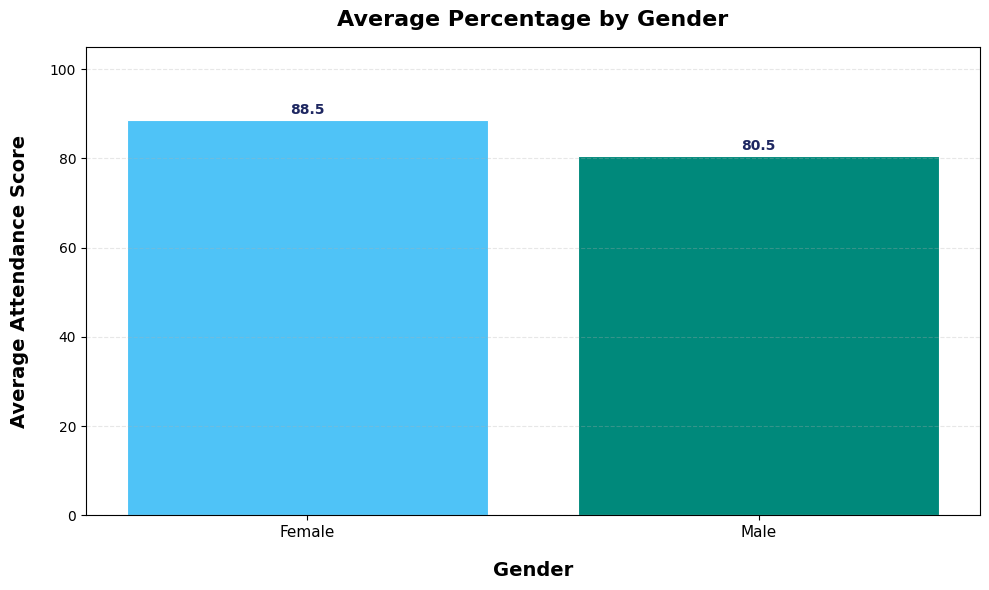

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

chart1_sql="""
SELECT gender,ROUND(AVG(attendance_percentage),2) AS avg_percentage
FROM students
GROUP BY gender
ORDER BY avg_percentage DESC
"""
chart1_df=pd.read_sql_query(chart1_sql,conn)

fig,ax=plt.subplots(figsize=(10,6))

bar_colors=['#4FC3F7','#00897B','#E67E32','#8E44AD'] # Corrected hex color code

bars=ax.bar(
    chart1_df['gender'], # Corrected variable name
    chart1_df['avg_percentage'],   # Corrected variable name
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

for bar in bars:
   height=bar.get_height()
   ax.text(
       bar.get_x()+bar.get_width()/2,
       height+0.8,
       f'{height:.1f}', # Changed to .1f for one decimal place
       ha='center',
       va='bottom',
       fontsize=10,
       fontweight='bold',
       color='#1E2761'
   )

# Moved these plotting commands outside the loop
ax.set_title('Average Percentage by Gender',fontsize=16,fontweight='bold',pad=15)
ax.set_xlabel('Gender',fontsize=14,fontweight='bold',labelpad=15)
ax.set_ylabel('Average Attendance Score',fontsize=14,fontweight='bold',labelpad=15)
ax.set_ylim(0,105)
ax.tick_params(axis='x',labelsize=11)
ax.grid(axis='y',alpha=0.3,linestyle='--')

plt.tight_layout()
plt.show()

In [ ]:
query6= """
SELECT gender,
ROUND(AVG(programming_score)) AS avg_programming_score
FROM students
WHERE gender= 'Female'
"""
def run_query(query, label):
    cursor.execute(query)
    results = cursor.fetchall()
    print(label)
    for row in results:
        print(row)
run_query(query6,"Query 6")

Query 6
('Female', 70.0)


In [ ]:
query7 = """
SELECT
department,
ROUND(AVG(attendance_percentage),2) AS avg_percentage
FROM students
GROUP BY department
HAVING avg_percentage>85
ORDER BY avg_percentage desc
"""
def run_query(query, title):
    cursor.execute(query)
    results = cursor.fetchall()
    print(title)
    for row in results:
        print(row)
run_query(query7,"Query7:")

Query7:
('Computer Science', 90.69)


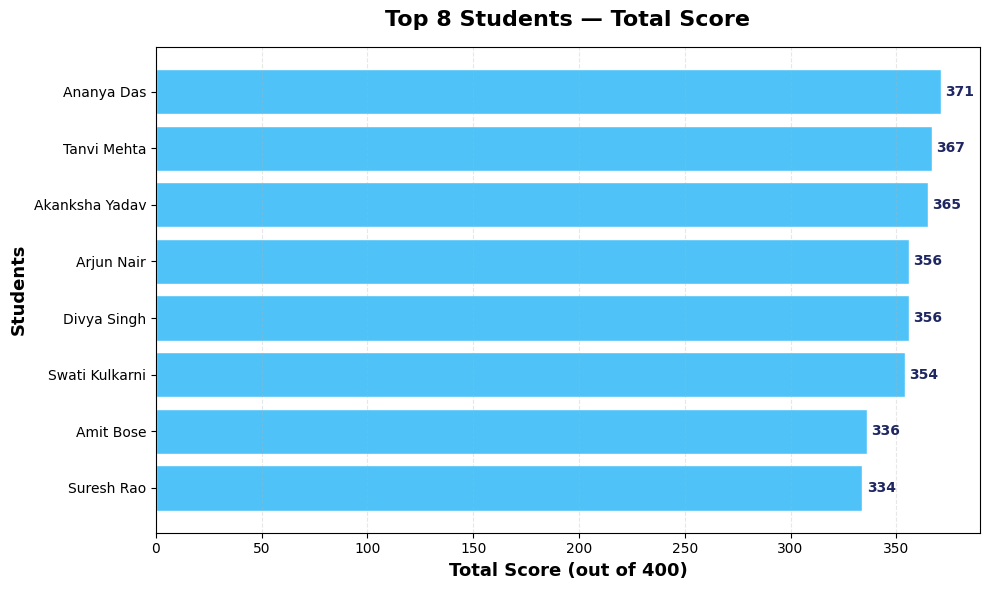

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# SQL Query for Top 8 students
chart2_sql = """
SELECT
    name,
    (math_score + english_score + science_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

# Read SQL query
chart2_df = pd.read_sql_query(chart2_sql, conn)

# Create figure
fig, ax = plt.subplots(figsize=(10,6))

# Horizontal bar chart
bars = ax.barh(
    chart2_df['name'],
    chart2_df['total_score'],
    color='#4FC3F7',
    edgecolor='white',
    linewidth=1
)

# Highest score at top
ax.invert_yaxis()

# Add score labels
for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 2,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#1E2761'
    )

# Titles and labels
ax.set_title(
    'Top 8 Students — Total Score',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Total Score (out of 400)',
    fontsize=13,
    fontweight='bold'
)

ax.set_ylabel(
    'Students',
    fontsize=13,
    fontweight='bold'
)

# Grid
ax.grid(axis='x', linestyle='--', alpha=0.3)

# Layout
plt.tight_layout()

# Show plot
plt.show()

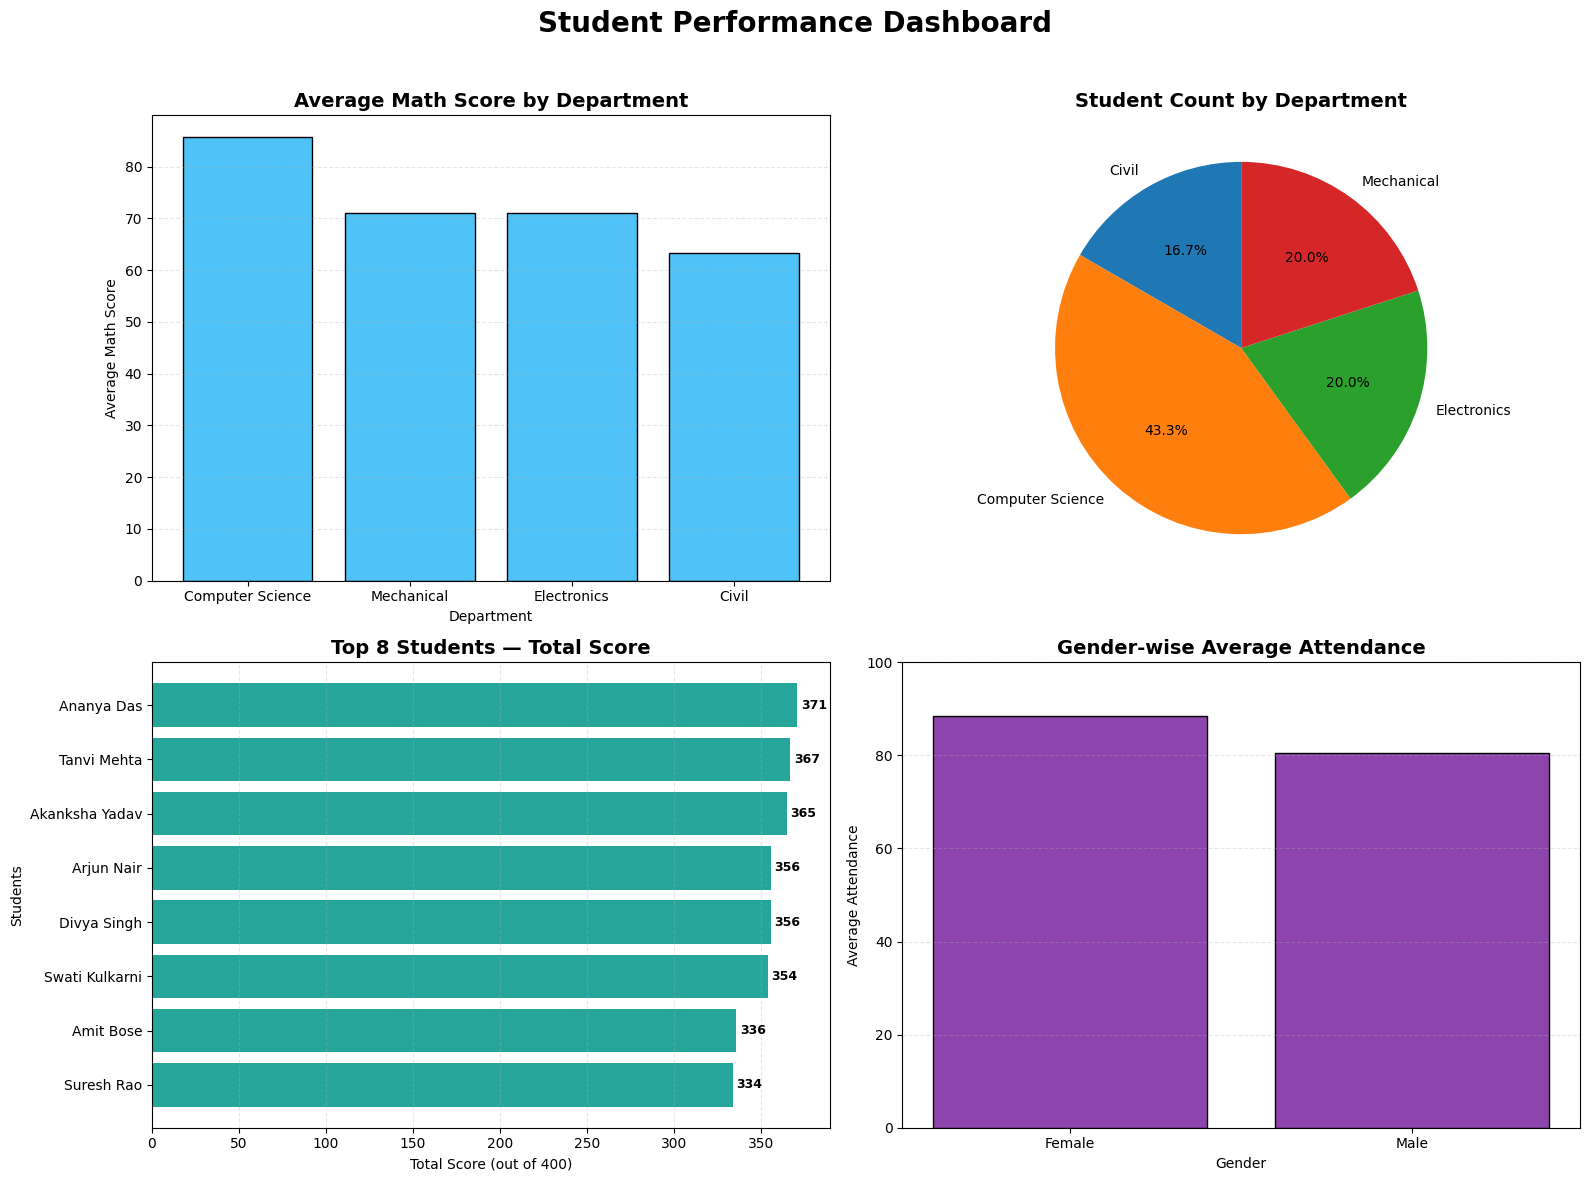

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# PANEL 1 → Avg Math by Department
# =========================
panel1_sql = """
SELECT
    department,
    ROUND(AVG(math_score),2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""

panel1_df = pd.read_sql_query(panel1_sql, conn)

# =========================
# PANEL 2 → Student Count by Department
# =========================
panel2_sql = """
SELECT
    department,
    COUNT(*) AS student_count
FROM students
GROUP BY department
"""

panel2_df = pd.read_sql_query(panel2_sql, conn)

# =========================
# PANEL 3 → Top 8 Students by Total Score
# =========================
panel3_sql = """
SELECT
    name,
    (math_score + english_score + science_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

panel3_df = pd.read_sql_query(panel3_sql, conn)

# =========================
# PANEL 4 → Gender-wise Average Attendance
# =========================
panel4_sql = """
SELECT
    gender,
    ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY gender
ORDER BY avg_attendance DESC
"""

panel4_df = pd.read_sql_query(panel4_sql, conn)

# =========================================================
# CREATE 2x2 DASHBOARD
# =========================================================
fig, axs = plt.subplots(2, 2, figsize=(16,12))

# =========================================================
# PANEL 1 (TOP-LEFT)
# Avg Math by Department → BAR CHART
# =========================================================
axs[0,0].bar(
    panel1_df['department'],
    panel1_df['avg_math'],
    color='#4FC3F7',
    edgecolor='black'
)

axs[0,0].set_title(
    'Average Math Score by Department',
    fontsize=14,
    fontweight='bold'
)

axs[0,0].set_xlabel('Department')
axs[0,0].set_ylabel('Average Math Score')

axs[0,0].grid(axis='y', linestyle='--', alpha=0.3)

# =========================================================
# PANEL 2 (TOP-RIGHT)
# Student Count → PIE CHART
# =========================================================
axs[0,1].pie(
    panel2_df['student_count'],
    labels=panel2_df['department'],
    autopct='%1.1f%%',
    startangle=90
)

axs[0,1].set_title(
    'Student Count by Department',
    fontsize=14,
    fontweight='bold'
)

# =========================================================
# PANEL 3 (BOTTOM-LEFT)
# Top 8 Students → HORIZONTAL BAR
# =========================================================
bars = axs[1,0].barh(
    panel3_df['name'],
    panel3_df['total_score'],
    color='#26A69A'
)

axs[1,0].invert_yaxis()

axs[1,0].set_title(
    'Top 8 Students — Total Score',
    fontsize=14,
    fontweight='bold'
)

axs[1,0].set_xlabel('Total Score (out of 400)')
axs[1,0].set_ylabel('Students')

axs[1,0].grid(axis='x', linestyle='--', alpha=0.3)

# Add labels
for bar in bars:
    width = bar.get_width()

    axs[1,0].text(
        width + 2,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

# =========================================================
# PANEL 4 (BOTTOM-RIGHT)
# Gender Average Attendance → BAR CHART
# =========================================================
axs[1,1].bar(
    panel4_df['gender'],
    panel4_df['avg_attendance'],
    color='#8E44AD',
    edgecolor='black'
)

axs[1,1].set_title(
    'Gender-wise Average Attendance',
    fontsize=14,
    fontweight='bold'
)

axs[1,1].set_xlabel('Gender')
axs[1,1].set_ylabel('Average Attendance')

axs[1,1].set_ylim(0,100)

axs[1,1].grid(axis='y', linestyle='--', alpha=0.3)

# =========================================================
# MAIN TITLE
# =========================================================
fig.suptitle(
    'Student Performance Dashboard',
    fontsize=20,
    fontweight='bold'
)

# Spacing
plt.tight_layout(rect=[0,0,1,0.96])

# Show Dashboard
plt.show()

In [13]:
# =========================
# PANEL 1 → Avg Math by Department
# =========================
panel1_sql = """
SELECT
    department,
    ROUND(AVG(math_score),2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""

panel1_df = pd.read_sql_query(panel1_sql, conn)

print("Panel 1 Data: Average Math by Department")
print(panel1_df)

# =========================
# PANEL 2 → Student Count by Department
# =========================
panel2_sql = """
SELECT
    department,
    COUNT(*) AS student_count
FROM students
GROUP BY department
"""

panel2_df = pd.read_sql_query(panel2_sql, conn)

print("\nPanel 2 Data: Student Count by Department")
print(panel2_df)

# =========================
# PANEL 3 → Top 8 Students by Total Score
# =========================
panel3_sql = """
SELECT
    name,
    (math_score + english_score + science_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

panel3_df = pd.read_sql_query(panel3_sql, conn)

print("\nPanel 3 Data: Top 8 Students by Total Score")
print(panel3_df)

# =========================
# PANEL 4 → Gender-wise Average Attendance
# =========================
panel4_sql = """
SELECT
    gender,
    ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY gender
ORDER BY avg_attendance DESC
"""

panel4_df = pd.read_sql_query(panel4_sql, conn)

print("\nPanel 4 Data: Gender-wise Average Attendance")
print(panel4_df)

Panel 1 Data: Average Math by Department
         department  avg_math
0  Computer Science     85.62
1        Mechanical     71.00
2       Electronics     71.00
3             Civil     63.40

Panel 2 Data: Student Count by Department
         department  student_count
0             Civil              5
1  Computer Science             13
2       Electronics              6
3        Mechanical              6

Panel 3 Data: Top 8 Students by Total Score
             name  total_score
0      Ananya Das          371
1     Tanvi Mehta          367
2  Akanksha Yadav          365
3      Arjun Nair          356
4     Divya Singh          356
5  Swati Kulkarni          354
6       Amit Bose          336
7      Suresh Rao          334

Panel 4 Data: Gender-wise Average Attendance
   gender  avg_attendance
0  Female           88.53
1    Male           80.47


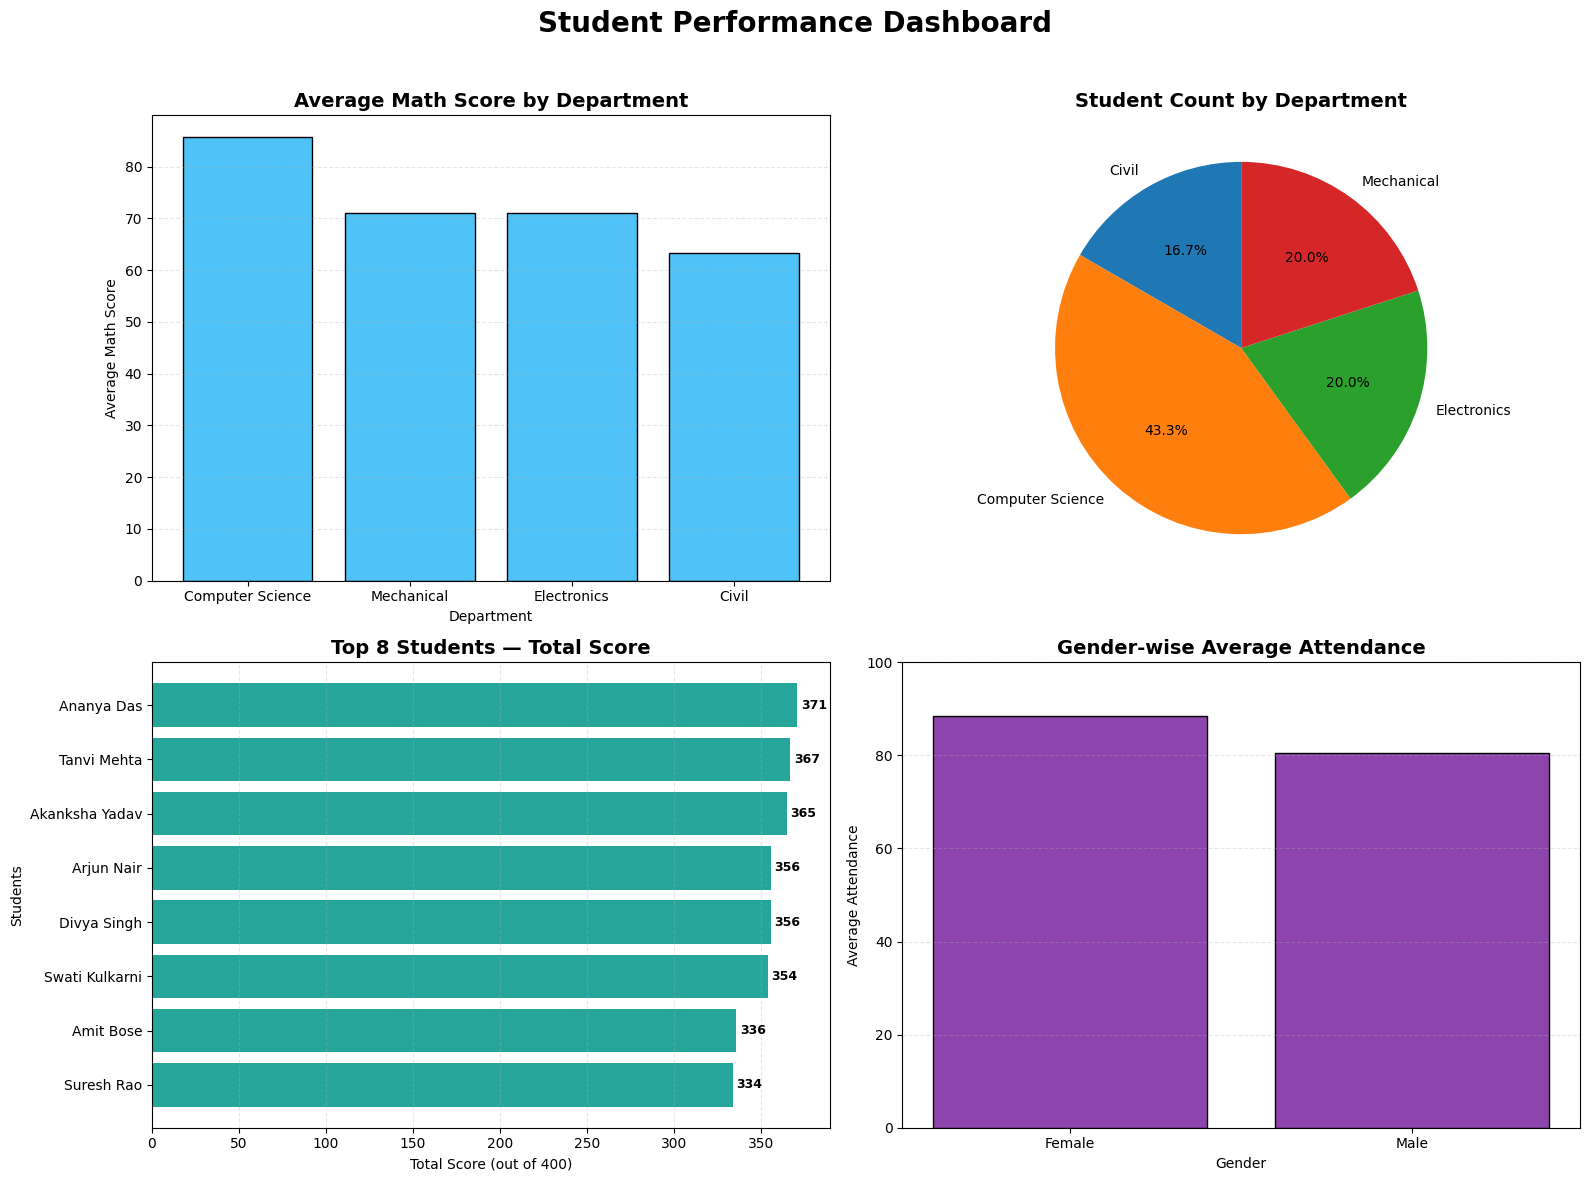

In [14]:
# =========================================================
# MATPLOTLIB DASHBOARD
# =========================================================

fig, axs = plt.subplots(2, 2, figsize=(16,12))

# =========================================================
# PANEL 1 (TOP-LEFT)
# Avg Math by Department → BAR CHART
# =========================================================
axs[0,0].bar(
    panel1_df['department'],
    panel1_df['avg_math'],
    color='#4FC3F7',
    edgecolor='black'
)

axs[0,0].set_title(
    'Average Math Score by Department',
    fontsize=14,
    fontweight='bold'
)

axs[0,0].set_xlabel('Department')
axs[0,0].set_ylabel('Average Math Score')

axs[0,0].grid(axis='y', linestyle='--', alpha=0.3)

# =========================================================
# PANEL 2 (TOP-RIGHT)
# Student Count → PIE CHART
# =========================================================
axs[0,1].pie(
    panel2_df['student_count'],
    labels=panel2_df['department'],
    autopct='%1.1f%%',
    startangle=90
)

axs[0,1].set_title(
    'Student Count by Department',
    fontsize=14,
    fontweight='bold'
)

# =========================================================
# PANEL 3 (BOTTOM-LEFT)
# Top 8 Students → HORIZONTAL BAR CHART
# =========================================================
bars = axs[1,0].barh(
    panel3_df['name'],
    panel3_df['total_score'],
    color='#26A69A'
)

axs[1,0].invert_yaxis()

axs[1,0].set_title(
    'Top 8 Students — Total Score',
    fontsize=14,
    fontweight='bold'
)

axs[1,0].set_xlabel('Total Score (out of 400)')
axs[1,0].set_ylabel('Students')

axs[1,0].grid(axis='x', linestyle='--', alpha=0.3)

# Add labels
for bar in bars:
    width = bar.get_width()

    axs[1,0].text(
        width + 2,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

# =========================================================
# PANEL 4 (BOTTOM-RIGHT)
# Gender Avg Attendance → BAR CHART
# =========================================================
axs[1,1].bar(
    panel4_df['gender'],
    panel4_df['avg_attendance'],
    color='#8E44AD',
    edgecolor='black'
)

axs[1,1].set_title(
    'Gender-wise Average Attendance',
    fontsize=14,
    fontweight='bold'
)

axs[1,1].set_xlabel('Gender')
axs[1,1].set_ylabel('Average Attendance')

axs[1,1].set_ylim(0,100)

axs[1,1].grid(axis='y', linestyle='--', alpha=0.3)

# =========================================================
# MAIN TITLE
# =========================================================
fig.suptitle(
    'Student Performance Dashboard',
    fontsize=20,
    fontweight='bold'
)

# Adjust spacing
plt.tight_layout(rect=[0,0,1,0.96])

# Show Dashboard
plt.show()